In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import joblib
from wrf_io import postproc
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_squared_error
import pickle

In [3]:
base_path = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'

In [32]:
params = {}

params['base_path']    = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'
params['kernel_file']  = '/results/annulus/wrf_10MW_ann_D3_result.txt'

params['train_data']   = '/train_data/wrf_10MW_ann.mat'

params['test_data']    = '/validation_data/wrf_10MW_ann.mat'

params['cot_scalar']   = '/train_data/scaler_wrf_cot_ann.pkl'
params['shear_scalar'] = '/train_data/scaler_shears_ann.pkl'
params['veer_scalar']  = '/train_data/scaler_veers_ann.pkl'
params['ind_scalar']   = '/train_data/scaler_wrf_ind_ann.pkl'
params['enc_scalar']   = '/train_data/encoder_ann.pkl'
# params['base_path'] = 
# params['base_path'] = 
# params['base_path'] = 
# params['base_path'] = 
# params['base_path'] = 

In [33]:
_, gpr = postproc.build_kernel_from_search(params, noise = True)

Kernel line:
ScoredKernel(k_opt=ProductKernel([ MaskKernel(ndim=8, active_dimension=3, base_kernel=RQKernel(lengthscale=1.078515, output_variance=0.958603, alpha=-7.338868)), SumKernel([ MaskKernel(ndim=8, active_dimension=0, base_kernel=RQKernel(lengthscale=-1.307137, output_variance=-0.683561, alpha=-2.603770)), MaskKernel(ndim=8, active_dimension=2, base_kernel=SqExpKernel(lengthscale=-1.036348, output_variance=-2.283321)) ]) ]), nll=-5229.826209, laplace_nle=nan, bic_nle=-10406.812527, noise=[-4.40948672])

Noise:
-4.40948672

Kernel specification string:
ProductKernel([ MaskKernel(ndim=8, active_dimension=3, base_kernel=RQKernel(lengthscale=1.078515, output_variance=0.958603, alpha=-7.338868)), SumKernel([ MaskKernel(ndim=8, active_dimension=0, base_kernel=RQKernel(lengthscale=-1.307137, output_variance=-0.683561, alpha=-2.603770)), MaskKernel(ndim=8, active_dimension=2, base_kernel=SqExpKernel(lengthscale=-1.036348, output_variance=-2.283321)) ]) ])

Kernel structure:
{'children'

In [34]:
X_train, y_train, X_test, y_test = postproc.extract_data(params, transform = False)

In [35]:
gpr.fit(X_train, y_train)

import pickle
import os

with open(os.path.join('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/results/annulus/opr_kernel.pkl'), 'wb') as f:
    pickle.dump(gpr, f)

In [28]:
A_pred = postproc.gpr_predict(params, gpr, set = 'test', std = False)

In [23]:
import pickle

with open(params['base_path'] + params['cot_scalar'], 'rb') as f:
    scalar_cot = pickle.load(f)

with open(params['base_path'] + params['ind_scalar'], 'rb') as f:
    scalar_ind = pickle.load(f)

y_scaled = scalar_cot.inverse_transform(X_test[:,0].reshape(-1, 1)).ravel()
x_test_scaled = scalar_ind.inverse_transform(y_test.reshape(-1, 1)).ravel()

In [29]:
np.sqrt(mean_squared_error(x_test_scaled, A_pred))

np.float64(0.006479355185555277)

In [4]:
# orig_kernel, opt_kernel_rot = postproc.build_kernel_from_search(base_path + '/results/annulus/wrf_10MW_ann_D3_result.txt')
orig_kernel, opt_kernel_rot = postproc.build_kernel_from_search(base_path + '/results/annulus_OH/wrf_10MW_ann_D1_result.txt',noise=True)

TypeError: string indices must be integers

In [27]:
postproc.compare_kernel_dict_and_sklearn(orig_kernel, opt_kernel_rot, tol=0.1, verbose=True)

root: PRODUCT: dict children: [{'type': 'mask', 'ndim': 4, 'active_dimension': 3, 'base_kernel': {'type': 'rq', 'lengthscale': 1.324849, 'variance': 1.351125, 'alpha': -7.592493}}, {'type': 'sum', 'children': [{'type': 'mask', 'ndim': 4, 'active_dimension': 0, 'base_kernel': {'type': 'rq', 'lengthscale': -1.909702, 'variance': -1.735414, 'alpha': -1.059517}}, {'type': 'mask', 'ndim': 4, 'active_dimension': 2, 'base_kernel': {'type': 'sqexp', 'lengthscale': 0.054731, 'variance': -0.782411}}]}]
root: PRODUCT: sk_children: [MaskedKernel(1.97**2 * RationalQuadratic(alpha=0.000504, length_scale=3.76), active_dims=[3]) * MaskedKernel(0.42**2 * RationalQuadratic(alpha=0.347, length_scale=0.148), active_dims=[0]) + MaskedKernel(0.676**2 * RBF(length_scale=1.06), active_dims=[2]), WhiteKernel(noise_level=0.0141)]
root.product[0]: Not a MaskedKernel, got MaskedKernel(1.97**2 * RationalQuadratic(alpha=0.000504, length_scale=3.76), active_dims=[3]) * MaskedKernel(0.42**2 * RationalQuadratic(alpha=

False

In [6]:
# Load training data
X_train_rot_mat = loadmat(base_path + '/train_data/wrf_10MW_OH_ann.mat')

X_train_rot = X_train_rot_mat['X']
y_train_rot = X_train_rot_mat['y'].ravel()

In [7]:
# Train the GP model
gpr = GaussianProcessRegressor(kernel=opt_kernel_rot, optimizer=None, normalize_y=False)
gpr.fit(X_train_rot, y_train_rot)

joblib.dump(gpr, '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW/results/annulus/wrf_10MW_OH_ann_GPR.pkl')

['/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW/results/annulus/wrf_10MW_OH_ann_GPR.pkl']

In [30]:
# Load test data
X_test_rot_mat = loadmat(base_path + '/test_data/wrf_10MW_ann.mat')

# Replace with the actual file path
with open(base_path + '/train_data/scaler_wrf_cot_ann.pkl', 'rb') as f:
    scalar_cot_ann = pickle.load(f)

with open(base_path + '/train_data/scaler_shears_ann.pkl', 'rb') as f:
    scalar_shear_ann = pickle.load(f)

with open(base_path + '/train_data/scaler_veers_ann.pkl', 'rb') as f:
    scalar_veer_ann = pickle.load(f)

with open(base_path + '/train_data/scaler_wrf_ind_ann.pkl', 'rb') as f:
    scalar_ind_ann = pickle.load(f)

X_test_rot_gpr = X_test_rot_mat['X']
# y_test_rot = X_test_rot_mat['y']

In [31]:
A_pred, sigma = gpr.predict(X_test_rot_gpr, return_std=True)

X_test_rot = np.zeros((2340,4))
X_test_rot[:,0] = X_test_rot_mat['X'][:,0].reshape(-1, 1).ravel()
X_test_rot[:,1] = scalar_cot_ann.inverse_transform(X_test_rot_mat['X'][:,1].reshape(-1, 1)).ravel()
X_test_rot[:,2] = scalar_shear_ann.inverse_transform(X_test_rot_mat['X'][:,2].reshape(-1, 1)).ravel()
X_test_rot[:,3] = scalar_veer_ann.inverse_transform(X_test_rot_mat['X'][:,3].reshape(-1, 1)).ravel()
y_test_rot = scalar_ind_ann.inverse_transform(X_test_rot_mat['y'])

A_pred = scalar_ind_ann.inverse_transform(A_pred.reshape(-1, 1))

In [10]:
out_sample = [i for i, (r, ct, s, v) in enumerate(X_test_rot) if (abs(v) > 0.2 or abs(s) > 0.03)]

In [11]:
X_train_rot[:,1] = scalar_cot_ann.inverse_transform(X_train_rot[:,1].reshape(-1, 1)).ravel()
X_train_rot[:,2] = scalar_shear_ann.inverse_transform(X_train_rot[:,2].reshape(-1, 1)).ravel()
X_train_rot[:,3] = scalar_veer_ann.inverse_transform(X_train_rot[:,3].reshape(-1, 1)).ravel()
y_train_rot      = scalar_ind_ann.inverse_transform(y_train_rot.reshape(-1, 1)).ravel()

X_train_rot[:,2] = np.round(X_train_rot[:,2], 2)
X_train_rot[:,3] = np.round(X_train_rot[:,3], 2)

In [24]:
uniform = [i for i, (r, ct, s, v) in enumerate(X_train_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]
# vhigh = [i for i, (r, ct, s, v) in enumerate(X_train_rot) if (v >= 0.2 and abs(s) < 0.01)]
# vlow  = [i for i, (r, ct, s, v) in enumerate(X_train_rot) if (v <= -0.2 and abs(s) < 0.01)]
vhigh = [i for i, (r, ct, s, v) in enumerate(X_train_rot) if (s >= 0.03 and abs(v) < 0.01)]
vlow = [i for i, (r, ct, s, v) in enumerate(X_train_rot) if (s <= -0.03 and abs(v) < 0.01)]

superposition = [i for i, (r, ct, s, v) in enumerate(X_train_rot) if (s >= 0.03 and v >= 0.2)]

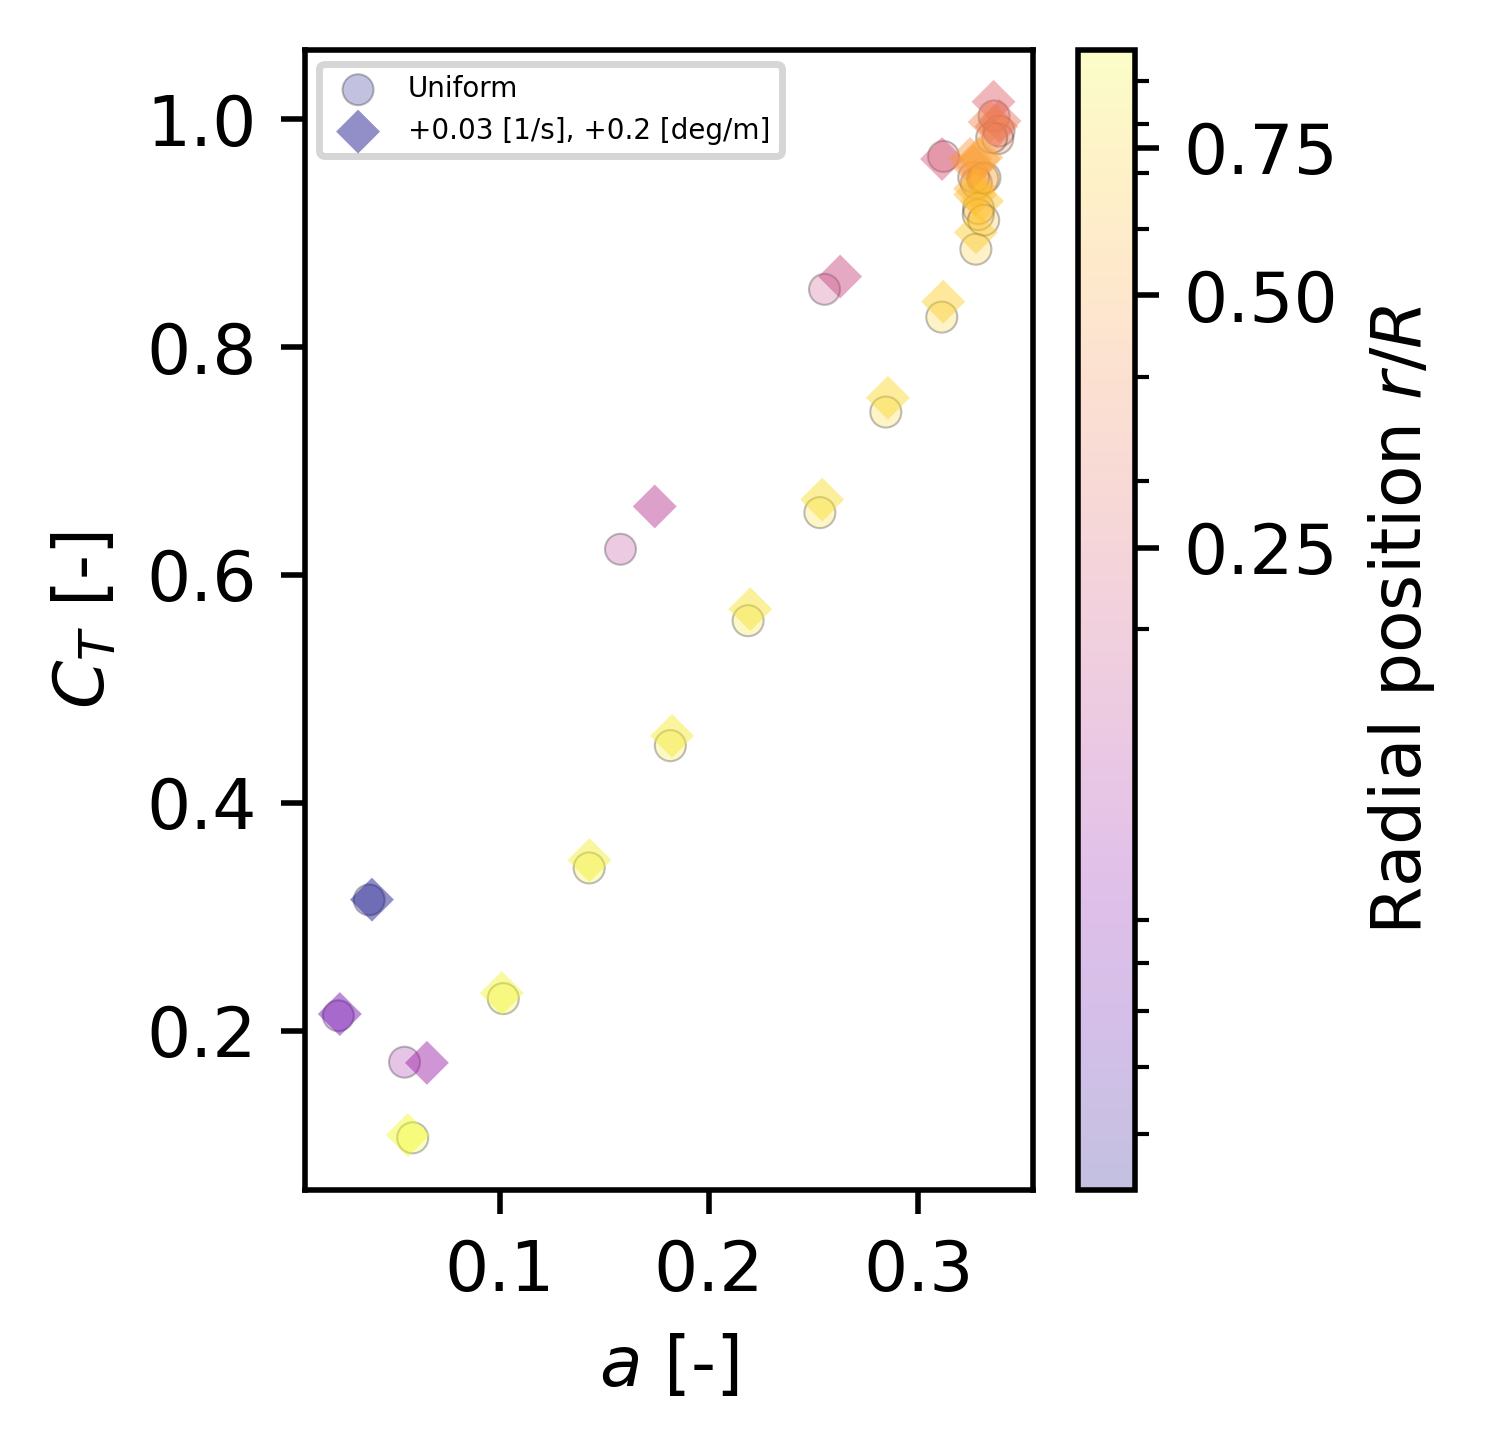

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Select uniform inflow cases (low shear & veer)
# uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]

# Extract values
r_vals  = X_train_rot[uniform, 0]
a_vals  = y_train_rot[uniform]
ct_vals = X_train_rot[uniform, 1]

# Create the scatter plot using actual r_vals for color
fig, ax = plt.subplots(figsize=(3, 3))
# sc = ax.scatter(a_vals, ct_vals, s=10, c=r_vals, cmap='viridis', marker='s', edgecolor='none', alpha=1.0)

import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=r_vals.min(), vmax=r_vals.max())

sc = ax.scatter(a_vals, ct_vals, s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='o', edgecolor='k', linewidth=0.3, alpha=0.25, label='Uniform')

# ax.scatter(y_train_rot[vlow], X_train_rot[vlow, 1], s=20, c=r_vals, cmap='plasma',
#                 norm=norm, marker='x', edgecolor='none', linewidth=0.3, alpha=0.9, label='No shear, -0.2 [deg/m]')

# ax.scatter(y_train_rot[vhigh], X_train_rot[vhigh, 1], s=20, c=r_vals, cmap='plasma',
#                 norm=norm, marker='+', edgecolor='none', linewidth=0.3, alpha=0.9, label='No shear, +0.2 [deg/m]')

# ax.scatter(y_train_rot[vlow], X_train_rot[vlow, 1], s=20, c=r_vals, cmap='plasma',
#                 norm=norm, marker='x', edgecolor='none', linewidth=0.3, alpha=0.9, label='-0.03 [1/s], No veer')

# ax.scatter(y_train_rot[vhigh], X_train_rot[vhigh, 1], s=20, c=r_vals, cmap='plasma',
#                 norm=norm, marker='+', edgecolor='none', linewidth=0.3, alpha=0.9, label='+0.03 [1/s], No veer')

ax.scatter(y_train_rot[superposition], X_train_rot[superposition, 1], s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='D', edgecolor='none', linewidth=0.3, alpha=0.45, label='+0.03 [1/s], +0.2 [deg/m]')

# cbar = plt.colorbar(sc, ax=ax)
cbar = plt.colorbar(sc, ax=ax, ticks=[0.25, 0.5, 0.75])
cbar.set_ticklabels(['0.25', '0.50', '0.75'])  # Optional: format to 2 decimals
cbar.set_label("Radial position $r/R$")

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
ax.legend(fontsize=4)
# ax.set_ylim([0.672,0.6952])

# Add colorbar that reflects radial position r
# cbar = plt.colorbar(sc, ax=ax, pad=0.02)
# cbar.set_label('Radial position $r/R$', fontsize=10)
# cbar.ax.tick_params(labelsize=8)



plt.tight_layout()
plt.show()


In [ ]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(y_t_rot[out_sample], X_t_rot[out_sample, 1], s=10, color='b', marker='r', label='Test data (out-of-sample)', edgecolor='none')
ax.scatter(A_pred[out_sample], X_t_rot[out_sample,1],4,color='r', label = 'GP Prediction',alpha=0.35,edgecolor='none')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

rmse = np.sqrt(mean_squared_error(y_t_rot[out_sample], A_pred[out_sample]))
ax.legend(fontsize=7, title=f"RMSE: {rmse:.2e}")
rmse

np.float64(0.009363016710125871)

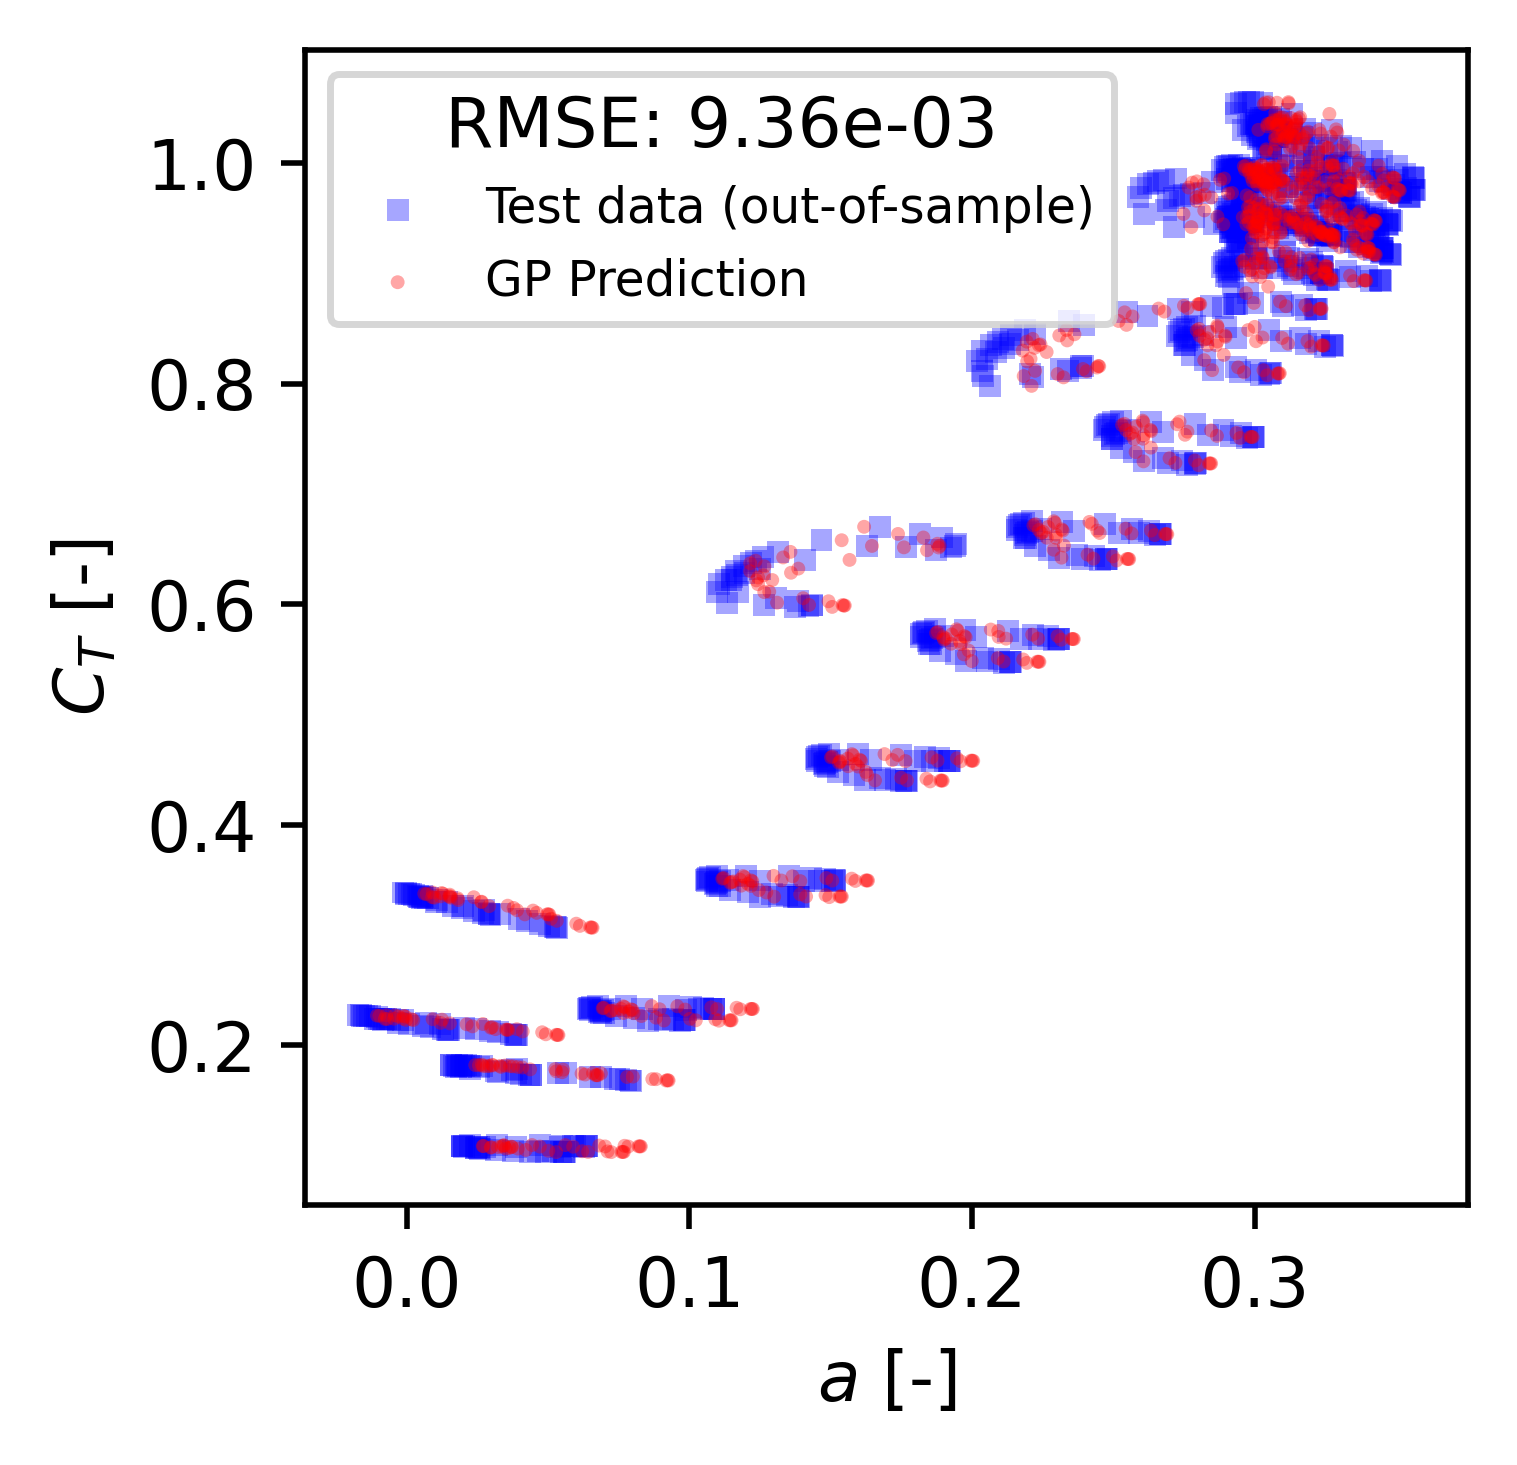

In [32]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

# ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
# ax.plot(a_mad,ct_mad,'k--',zorder=1)
# ax.scatter(y_train,X_train[:,0],color='b')

ax.scatter(y_test_rot[out_sample], X_test_rot[out_sample, 1], s=10, color='b', marker='s', label='Test data (out-of-sample)', alpha=0.35,edgecolor='none')
# ax.scatter(y_t_rot[out_sample], X_t_rot[out_sample, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')
# ax.scatter(y_t_rot[in_sample], X_t_rot[in_sample, 0], s=20, color='b', marker='o', label='Test data (in-sample)')

ax.scatter(A_pred[out_sample],X_test_rot[out_sample,1],4,color='r', label = 'GP Prediction',alpha=0.35,edgecolor='none')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

rmse = np.sqrt(mean_squared_error(y_test_rot[out_sample], A_pred[out_sample]))
ax.legend(fontsize=7, title=f"RMSE: {rmse:.2e}")
rmse

In [17]:
len(out_sample)

884

In [20]:
len(in_sample)

1456

np.float64(0.009202176589318694)

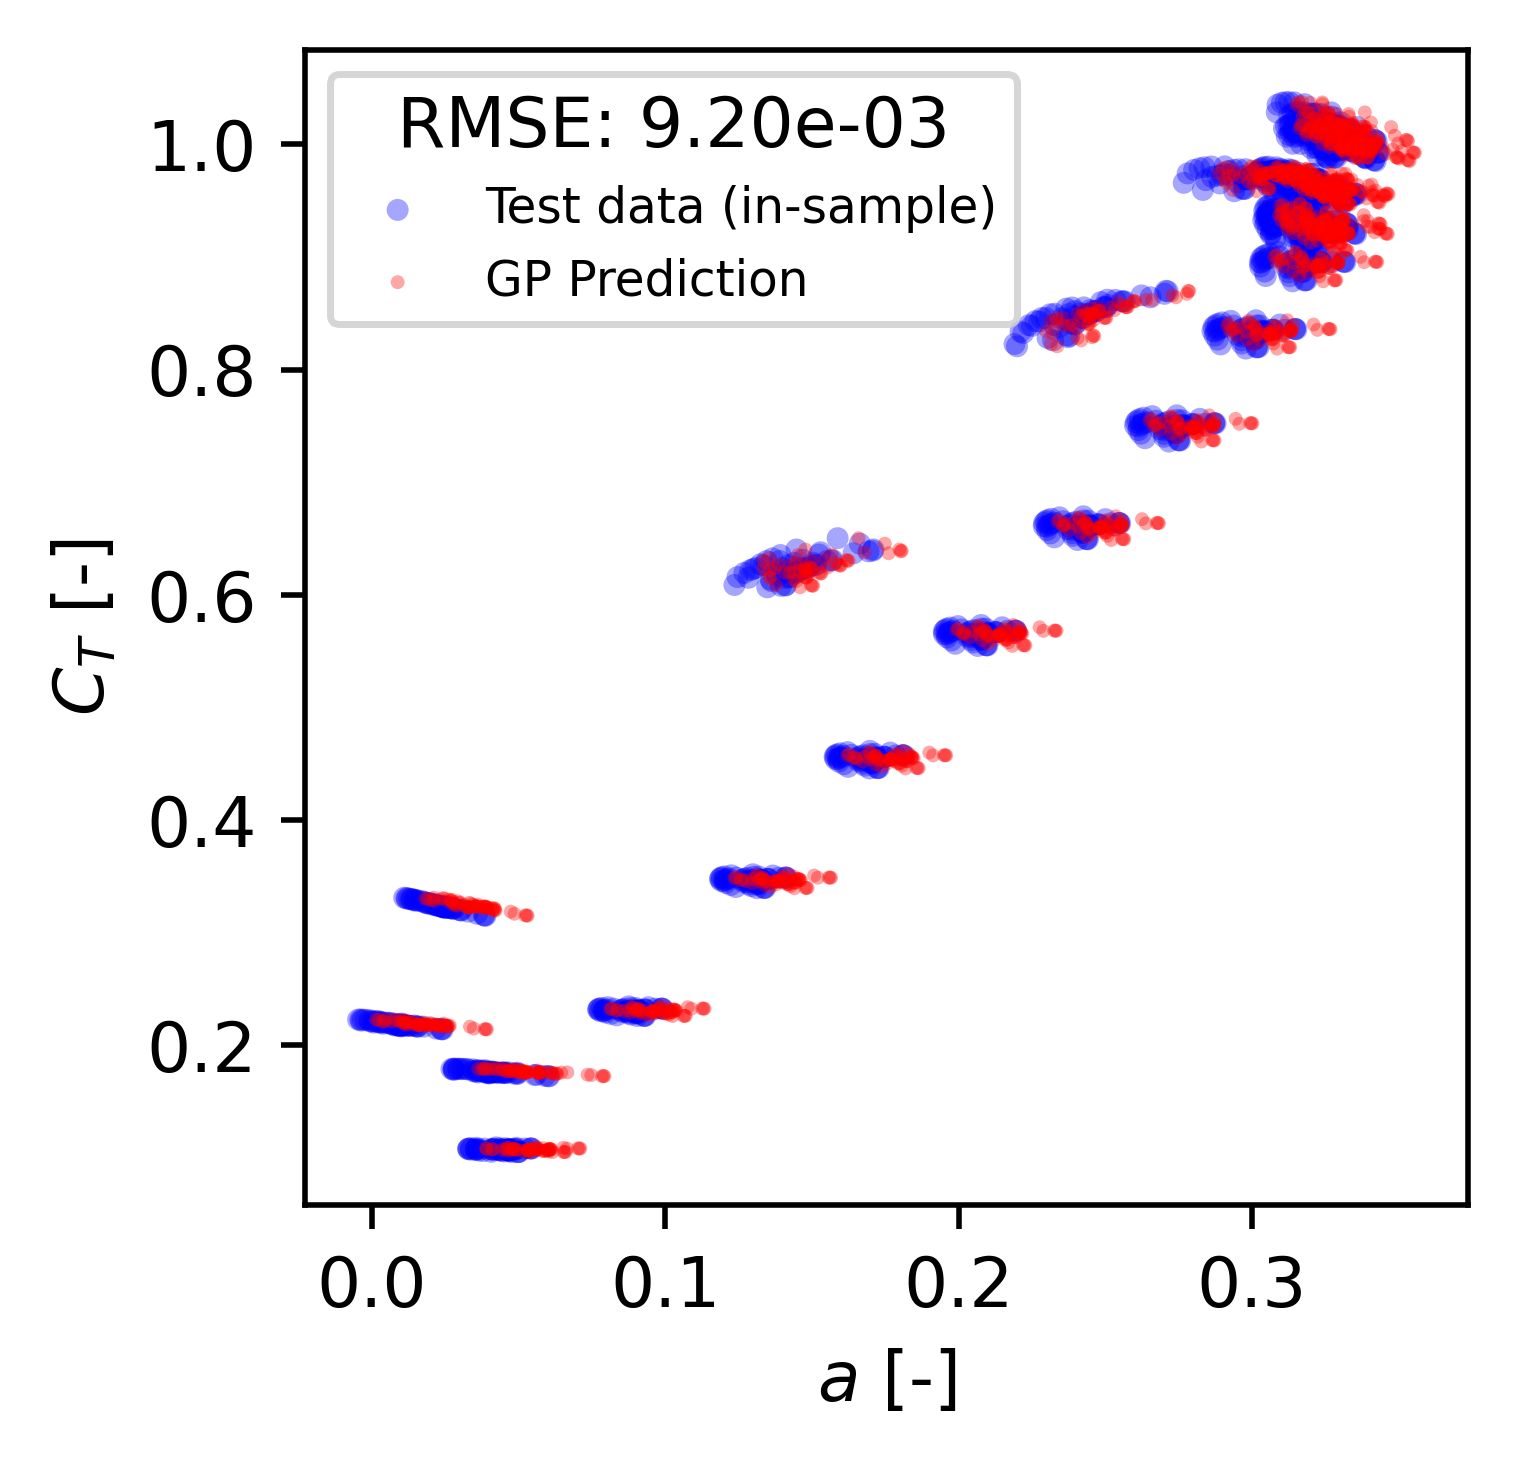

In [33]:
full_range = np.arange(0, len(X_test_rot))  # inclusive of 90
in_sample = np.setdiff1d(full_range, out_sample)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

# ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
# ax.plot(a_mad,ct_mad,'k--',zorder=1)
# ax.scatter(y_train,X_train[:,0],color='b')

ax.scatter(y_test_rot[in_sample], X_test_rot[in_sample, 1], s=10, color='b', label='Test data (in-sample)', alpha=0.35,edgecolor='none')
# ax.scatter(y_t_rot[out_sample], X_t_rot[out_sample, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')
# ax.scatter(y_t_rot[in_sample], X_t_rot[in_sample, 0], s=20, color='b', marker='o', label='Test data (in-sample)')

ax.scatter(A_pred[in_sample],X_test_rot[in_sample,1],4,color='r', label = 'GP Prediction', alpha=0.35,edgecolor='none')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

rmse = np.sqrt(mean_squared_error(y_test_rot[in_sample], A_pred[in_sample]))
ax.legend(fontsize=7, title=f"RMSE: {rmse:.2e}")
rmse

In [35]:
rmse

np.float64(0.001606680491155459)

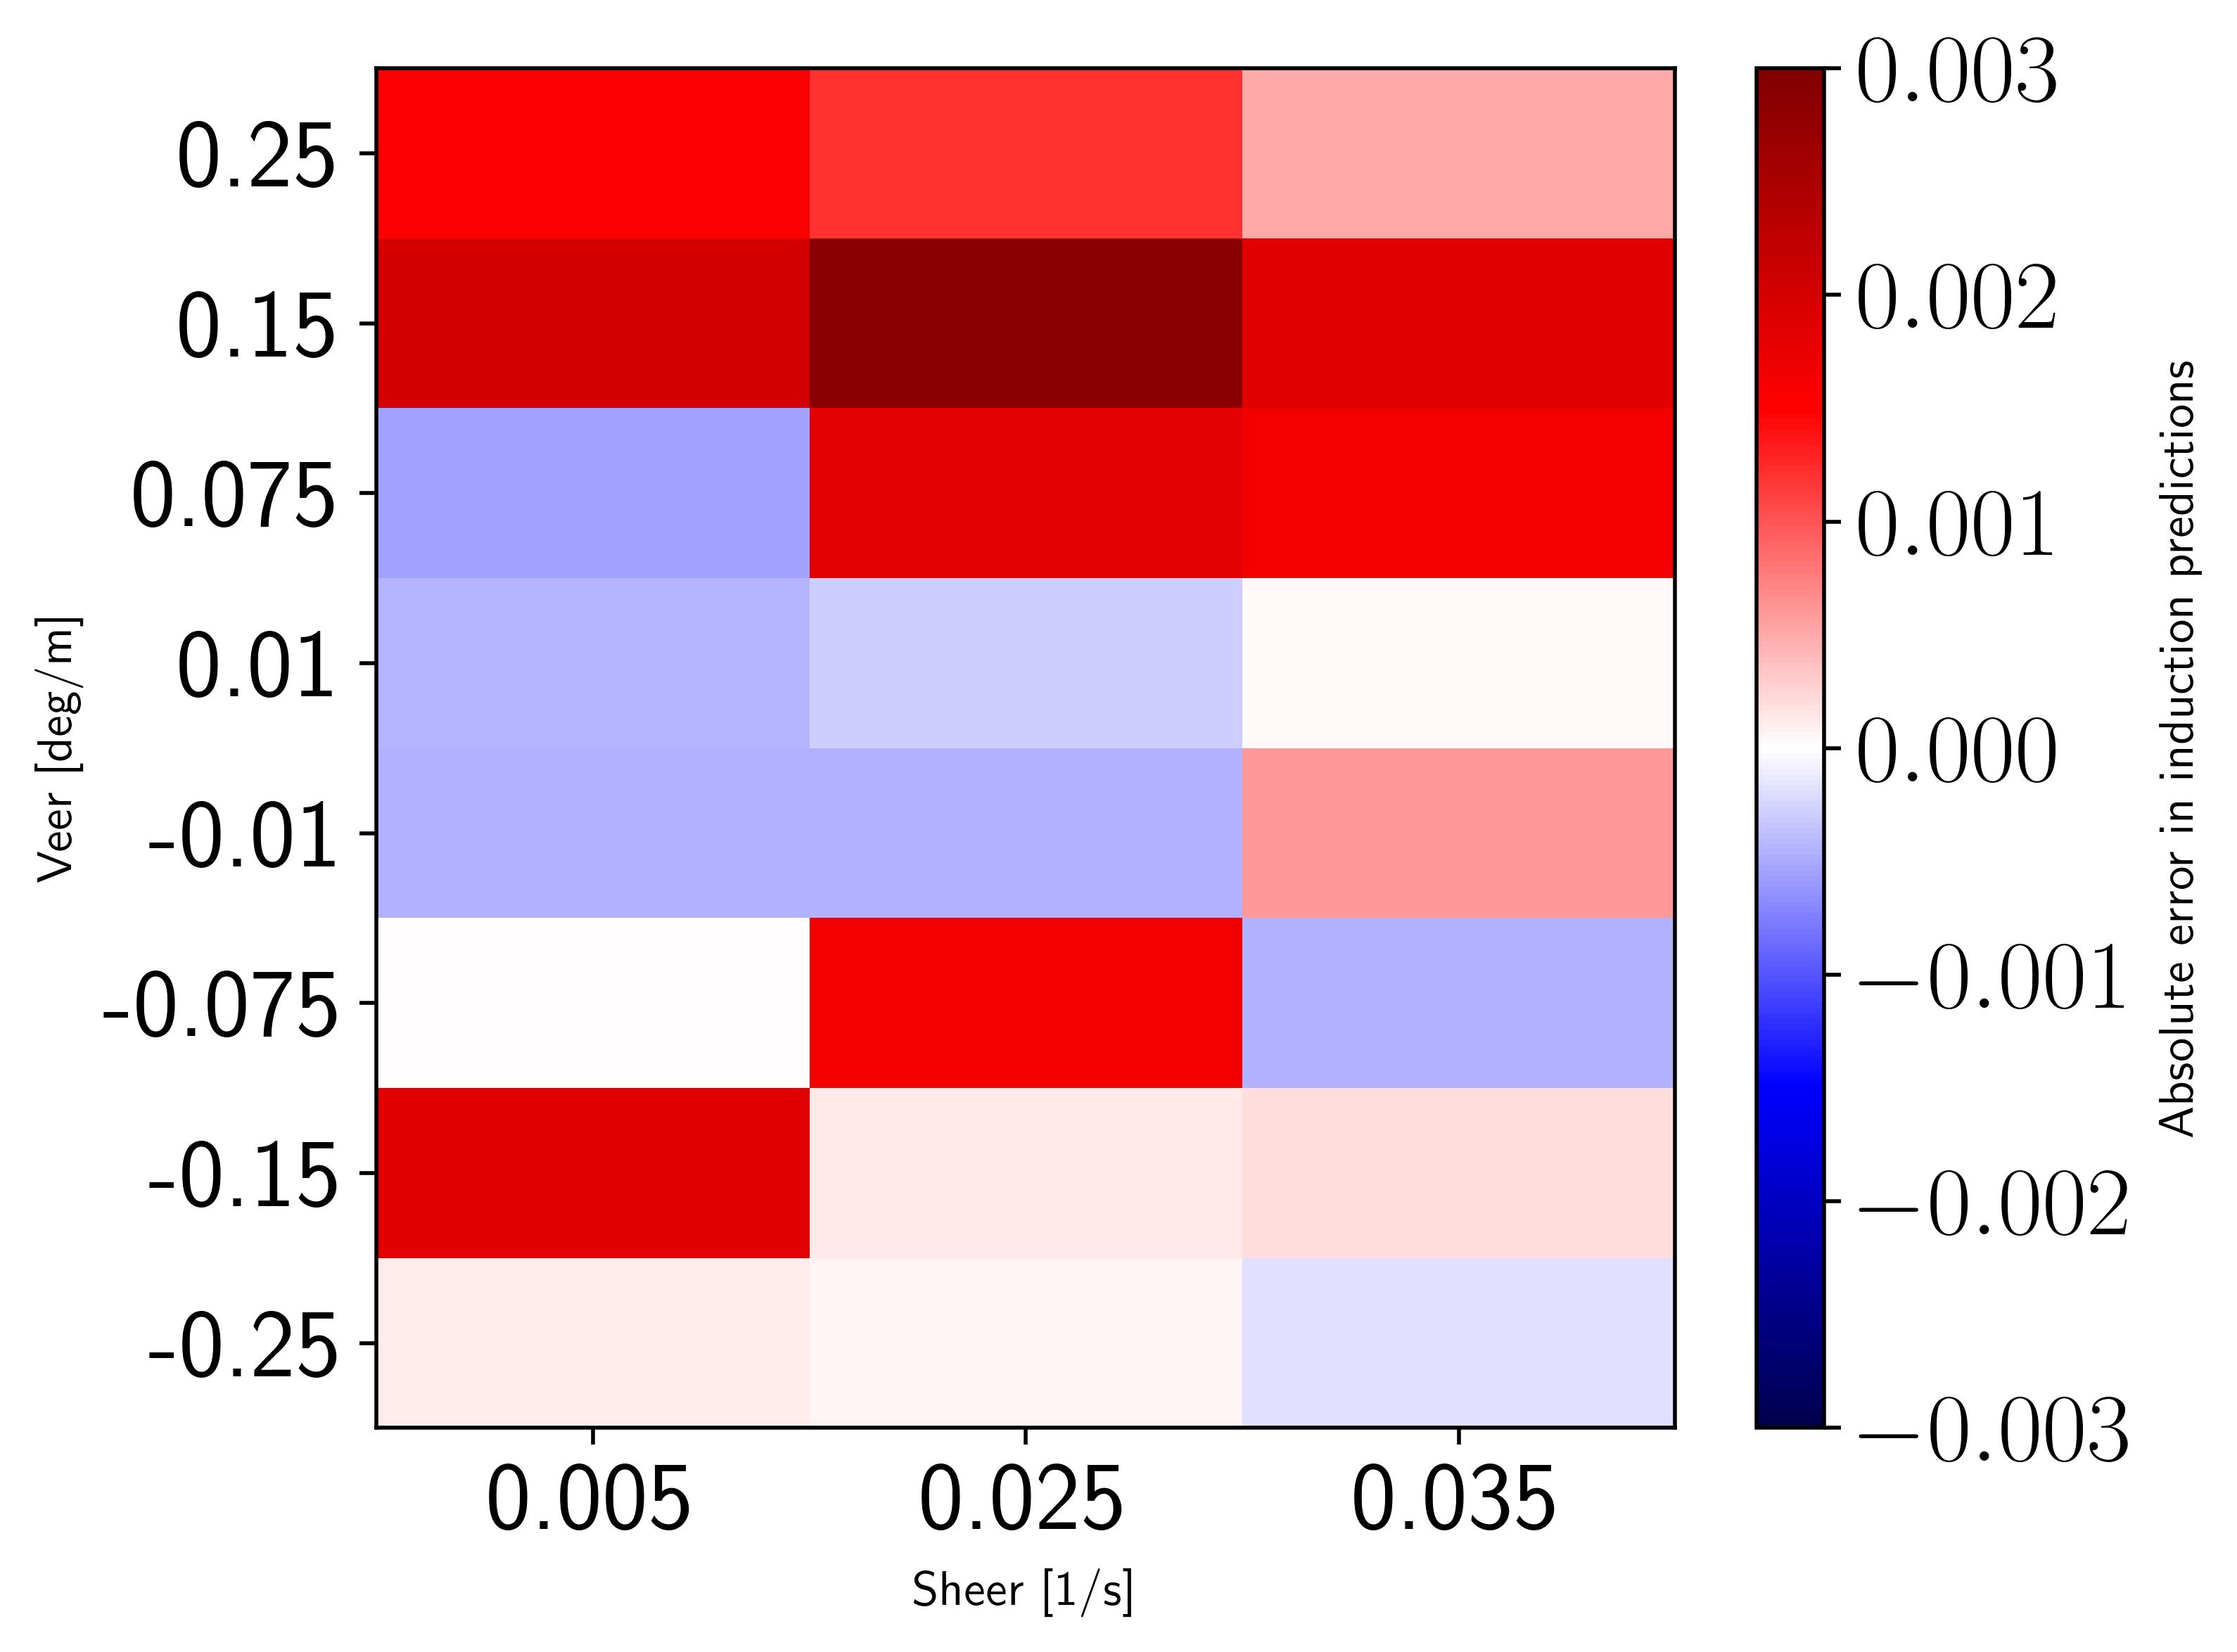

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D data
data = (y_test - A_pred).reshape(8,3)
# data = A_pred.reshape(8,3)


# Define the edges of the grid (must be one more than data.shape)
x_edges = np.arange(data.shape[1] + 1)  # 4 edges for 3 columns
y_edges = np.arange(data.shape[0] + 1)  # 5 edges for 4 rows

r's035_v010',
r's035_v075',
r's035_v150',
r's035_v250',
r's035_vn010',
r's035_vn075',
r's035_vn150',
r's035_vn250',

# Define tick labels you want to appear at cell centers
x_tick_labels = ['0.005', '0.025', '0.035']
y_tick_labels = ['-0.25','-0.15','-0.075','-0.01','0.01','0.075','0.15','0.25']

# Compute centers of the grid cells (midpoints between edges)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Set custom tick locations (centers of cells)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Plot
fig, ax = plt.subplots()
mesh = ax.pcolormesh(x_edges, y_edges, data, shading='auto', cmap='seismic',vmin=-0.003,vmax=0.003)

# Set ticks at cell centers
ax.set_xticks(x_centers)
ax.set_xticklabels(x_tick_labels)

ax.set_yticks(y_centers)
ax.set_yticklabels(y_tick_labels)

# Optional: add a colorbar
plt.colorbar(mesh, ax=ax, label='Absolute error in induction predictions')
plt.ylabel('Veer [deg/m]')
plt.xlabel('Sheer [1/s]')
plt.tight_layout()
plt.show()

In [167]:
data

array([[ 1.15015338e-04,  6.17230698e-05, -1.84967757e-04],
       [ 1.85704842e-03,  1.30309843e-04,  2.09168802e-04],
       [ 1.77425064e-05,  1.64617297e-03, -4.59429252e-04],
       [-4.67581334e-04, -4.47170470e-04,  5.99205096e-04],
       [-4.36760437e-04, -3.03059934e-04,  4.23056248e-05],
       [-5.56503308e-04,  1.82728353e-03,  1.64561741e-03],
       [ 2.01242809e-03,  2.86916226e-03,  1.85984577e-03],
       [ 1.55106164e-03,  1.20155882e-03,  5.00825900e-04]])

In [92]:
A_pred

array([0.25194899, 0.24890544, 0.24874281, 0.24912277, 0.2498527 ,
       0.25097282, 0.25247105, 0.25648237, 0.26755682])

In [ ]:
D1_ormse = 0.022602774542255486
D2_ormse = 0.01344897579142045
D3_ormse = 0.009363016710125871
D4_ormse = 0.01949539736016311
D5_ormse = 0.030720010749418807

ormses = [D1_ormse, D2_ormse, D3_ormse, D4_ormse, D5_ormse]

In [13]:
D1_irmse = 0.010327483756894736
D2_irmse = 0.011274623898450086
D3_irmse = 0.009202176589318694
D4_irmse = 0.009346370988415644
D5_irmse = 0.00938489349571194

irmses = [D1_irmse, D2_irmse, D3_irmse, D4_irmse, D5_irmse]

depth = [1,2,3,4,5]

In [30]:

depth = [1,2,3,4]

irmses = [0.012964604740933168,
          0.010798111943564396,
          0.005518447707129607,
          0.006479355185555277]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


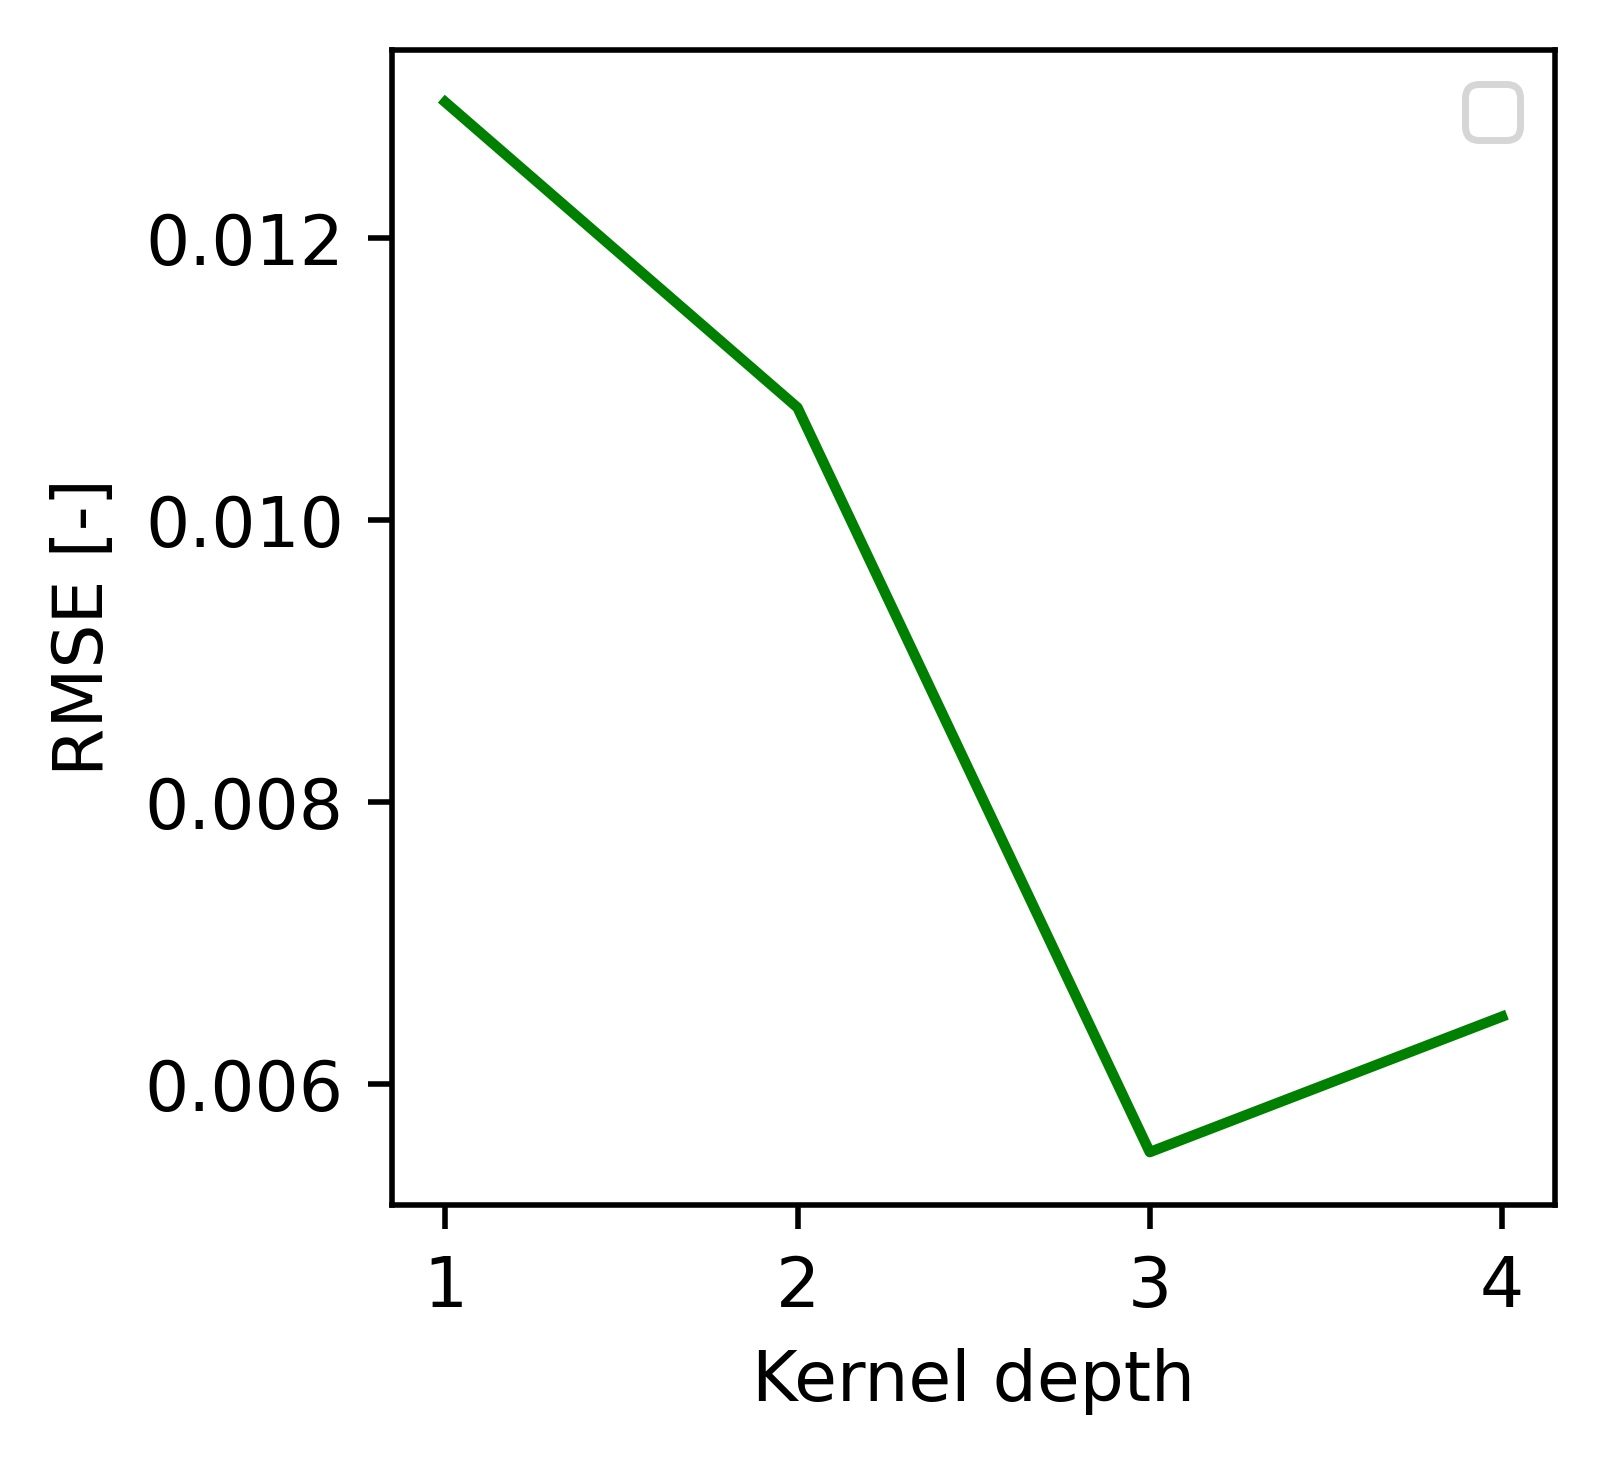

In [31]:
fig, ax = plt.subplots(figsize=(3, 3))

# ax.plot(depth,ormses, color='r', label='out-of-sample')
ax.plot(depth,irmses, color='g', label='')
ax.set_ylabel('RMSE [-]')
ax.set_xlabel('Kernel depth')
ax.legend()